# Analyse des résultats — évaluations RAGAS du prototype

Charge tous les runs disponibles dans `eval/results/` (un fichier `<label>.json` par run, produit par `evaluate_ragas.py --label <label>`). Aucun run n'en écrase un autre.

| Run | Système évalué |
|---|---|
| `baseline` | prototype d'origine (texte libre, client Mistral direct, aucune validation) |
| `validation_pydantic` | + couche de validation Pydantic complète : **entrée** (pipeline chunking/embedding et chunks récupérés validés) et **sortie** (`RAGAnswer` structurée, citations vérifiées, abstention possible). Prompt et température inchangés. |

**Structure** : chaque run est analysé indépendamment dans sa propre section (sections 1 et 2), avec exactement le même traitement. La comparaison entre runs est isolée en section 3, pour ne pas mélanger constat et évolution.

Chaque analyse de run couvre deux axes distincts :
- **qualité RAGAS** — 4 métriques jugées par gpt-4o ;
- **comportement d'abstention** — comparaison déterministe `abstain` × `expected_behavior`, sans juge LLM (uniquement disponible pour les runs postérieurs à la sortie structurée).

**Note de lecture pour les cas "bruitée"** : la `reference_answer` de ces cas est l'aveu explicite d'une limite (donnée absente, ambiguë...). Un score élevé signifie donc que le système a correctement reconnu cette limite ; un score bas signifie qu'il a répondu avec assurance à une question qui n'avait pas de réponse fiable — c'est-à-dire qu'il a halluciné.

## 0. Chargement et fonctions d'analyse

Les fonctions ci-dessous sont appliquées à l'identique à chaque run, ce qui garantit que les sections 1 et 2 sont comparables sans être couplées.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path.cwd() / "results"
RUNS = ["baseline", "validation_pydantic"]  # ordre chronologique
METRICS = ["faithfulness", "context_precision", "context_recall", "answer_correctness"]
ORDRE_CATEGORIES = ["simple", "complexe", "bruitee"]
N_PIRES_CAS = 6  # nombre de cas dont on affiche le texte complet, par run

# Un run absent est simplement ignoré : le notebook reste exécutable avant/après
# chaque nouvelle évaluation.
runs = {}
for label in RUNS:
    path = RESULTS_DIR / f"{label}.json"
    if path.exists():
        runs[label] = pd.DataFrame(json.loads(path.read_text(encoding="utf-8")))

print("Runs chargés :", ", ".join(runs) or "aucun")
print("Runs absents :", ", ".join(r for r in RUNS if r not in runs) or "aucun")

Runs chargés : baseline, validation_pydantic
Runs absents : aucun


In [2]:
def analyser_abstention(d):
    """Axe comportemental : le système reconnaît-il qu'il ne peut pas répondre ?

    Mesure déterministe, sans juge LLM : croise le champ `abstain` (sortie structurée
    RAGAnswer) avec `expected_behavior` du testset. `expected_behavior` ne sert qu'ici,
    jamais à recalculer un score RAGAS.
    """
    if "abstain" not in d.columns:
        print("Axe non applicable : ce run précède la sortie structurée RAGAnswer.")
        return

    # Les cas en échec (ex. erreur 429 côté juge) n'ont ni abstain ni expected_behavior.
    # Les garder les compterait à tort comme des abstentions correctes, car bool(NaN) vaut True.
    c = d.dropna(subset=["abstain"])[
        ["id", "categorie", "expected_behavior", "abstain", "abstain_reason"]
    ].copy()
    exclus = len(d) - len(c)
    if exclus:
        print(f"{exclus} cas exclus (en échec, sans sortie structurée)")

    # astype(bool) : dès qu'un cas est en échec la colonne devient de type object, et
    # les opérations booléennes de pandas y deviennent binaires (~True donne -2)
    c["abstain"] = c["abstain"].astype(bool)
    # Tout expected_behavior autre que "answer" (abstain_absence, abstain_ambiguous,
    # flag_anomaly, flag_limitation) signifie : le système ne doit PAS répondre normalement
    c["devait_s_abstenir"] = c["expected_behavior"] != "answer"

    def classer(row):
        if row["devait_s_abstenir"]:
            return "abstention correcte" if row["abstain"] else "non-détection (répond quand même)"
        return "faux refus" if row["abstain"] else "réponse correcte"

    c["resultat"] = c.apply(classer, axis=1)

    # abstention_accuracy = part des cas où le comportement correspond à l'attendu
    ok = c["resultat"].isin(["abstention correcte", "réponse correcte"]).sum()
    print(f"abstention_accuracy : {ok}/{len(c)} = {ok / len(c):.1%}\n")
    print(c["resultat"].value_counts().to_string())
    display(c[["id", "categorie", "expected_behavior", "abstain", "resultat", "abstain_reason"]])


def analyser(label):
    """Analyse complète et autonome d'un run : scores globaux, par catégorie, par
    modalité, comportement d'abstention, puis texte des cas les plus faibles."""
    if label not in runs:
        print(f"Run '{label}' absent de results/ — rien à analyser pour l'instant.")
        return

    d = runs[label]
    manquants = d[METRICS].isna().any(axis=1).sum()
    print(f"===== Run '{label}' : {len(d)} cas, {manquants} avec des scores manquants =====\n")

    print("--- Scores moyens globaux ---")
    display(d[METRICS].mean().round(3).to_frame(label).T)

    par_cat = d.groupby("categorie")[METRICS].mean().round(3).reindex(ORDRE_CATEGORIES)
    par_mod = d.groupby("modalite")[METRICS].mean().round(3)
    print("--- Par catégorie ---")
    display(par_cat)
    print("--- Par modalité ---")
    display(par_mod)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    par_cat.plot(kind="bar", ax=axes[0], rot=0, legend=False)
    axes[0].set_title(f"{label} — par catégorie")
    par_mod.plot(kind="bar", ax=axes[1], rot=0, legend=False)
    axes[1].set_title(f"{label} — par modalité")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
    axes[0].set_ylabel("Score moyen (0-1)")
    handles, noms = axes[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Métrique", loc="upper right")
    plt.tight_layout()
    plt.show()

    print("--- Comportement d'abstention ---")
    analyser_abstention(d)

    print(f"--- Les {N_PIRES_CAS} cas les plus faibles (faithfulness) ---\n")
    for _, row in d.nsmallest(N_PIRES_CAS, "faithfulness").iterrows():
        print(f"=== {row['id']} ({row['categorie']} / {row['modalite']}) ===")
        print(
            f"faithfulness={row['faithfulness']:.2f}  context_precision={row['context_precision']:.2f}  "
            f"context_recall={row['context_recall']:.2f}  answer_correctness={row['answer_correctness']:.2f}"
        )
        print(f"\nQuestion : {row['question']}")
        print(f"\nRéponse de référence : {row['reference_answer']}")
        print(f"\nRéponse du système : {row['system_response']}")
        print("\n" + "-" * 100 + "\n")

## 1. Run `baseline` — prototype d'origine

Analyse autonome, sans référence à l'autre run.

===== Run 'baseline' : 18 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
baseline,0.335,0.262,0.528,0.234


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.461,0.308,0.500,0.343
complexe,0.414,0.312,0.500,0.208
bruitee,0.129,0.167,0.583,0.152


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.275,0.050,0.222,0.217
pdf_reddit,0.394,0.475,0.833,0.252


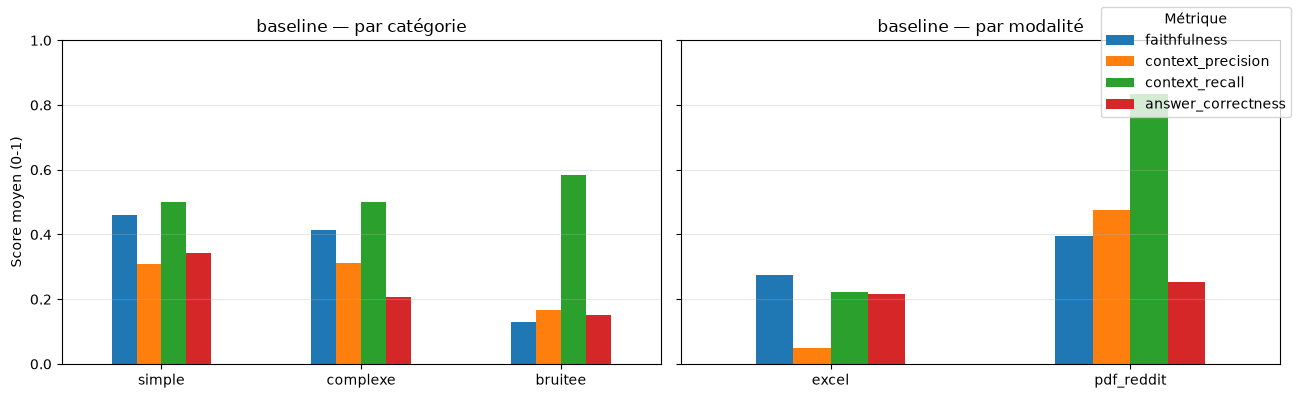

--- Comportement d'abstention ---
Axe non applicable : ce run précède la sortie structurée RAGAnswer.
--- Les 6 cas les plus faibles (faithfulness) ---

=== C1 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.13

Question : Quel joueur a le meilleur pourcentage de réussite à 3 points (3P%) parmi ceux ayant tenté plus de 300 tirs à 3 points cette saison ?

Réponse de référence : Zach LaVine, 44,6% sur 533 tentatives (3PA).

Réponse du système : D'après les données disponibles, voici l'analyse pour identifier le joueur avec le meilleur **3P%** parmi ceux ayant tenté **plus de 300 tirs à 3 points (3PA)** cette saison :

### **Top 5 des joueurs éligibles (3PA > 300) :**
*(Classés par 3P% décroissant)*

| **Joueur**               | **Équipe** | **3PA** | **3P%** | **PTS** | **FGM** | **FG%** |
|--------------------------|------------|---------|---------|---------|---------|---------|
| **Tyrese Haliburton**    | IND        | 320    

In [3]:
analyser("baseline")

## 2. Run `validation_pydantic` — avec la couche de validation Pydantic

Même traitement que la section 1, appliqué au run suivant.

===== Run 'validation_pydantic' : 18 cas, 1 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
validation_pydantic,0.667,0.268,0.559,0.295


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.700,0.270,0.600,0.352
complexe,0.662,0.312,0.500,0.264
bruitee,0.646,0.222,0.583,0.278


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.623,0.087,0.333,0.256
pdf_reddit,0.717,0.472,0.812,0.339


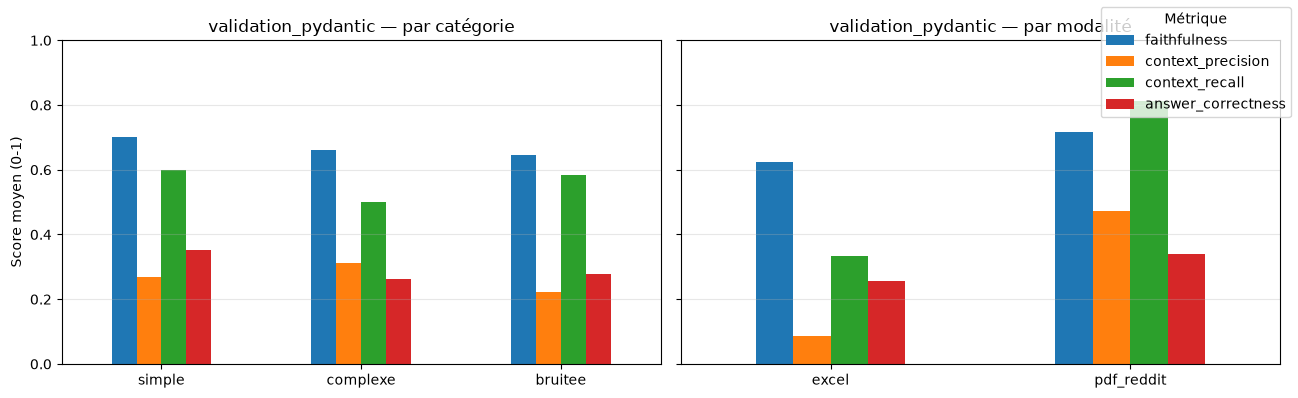

--- Comportement d'abstention ---
1 cas exclus (en échec, sans sortie structurée)
abstention_accuracy : 12/17 = 70.6%

resultat
réponse correcte                     9
abstention correcte                  3
non-détection (répond quand même)    3
faux refus                           2


,id,categorie,expected_behavior,abstain,resultat,abstain_reason
0,S1,simple,answer,True,faux refus,Donnée absente : le nom 'Nikola Jokić' n'appar...
1,S2,simple,answer,False,réponse correcte,None
2,S3,simple,answer,False,réponse correcte,None
3,S4,simple,answer,False,réponse correcte,None
4,S5,simple,answer,False,réponse correcte,None
6,C1,complexe,answer,True,faux refus,Les données ne fournissent pas d'informations ...
7,C2,complexe,answer,False,réponse correcte,None
8,C3,complexe,answer,False,réponse correcte,None
9,C4,complexe,answer,False,réponse correcte,None
10,C5,complexe,answer,False,réponse correcte,None


--- Les 6 cas les plus faibles (faithfulness) ---

=== C2 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.46

Question : Entre Nikola Jokić et Giannis Antetokounmpo, qui a le plus de rebonds totaux (REB) cette saison ?

Réponse de référence : Nikola Jokić, 889 REB, contre Giannis Antetokounmpo, 797 REB.

Réponse du système : D'après les données disponibles, **Nikola Jokić** a enregistré **1 069 rebonds totaux (REB)** cette saison, tandis que **Giannis Antetokounmpo** en a totalisé **987**. Ainsi, Jokić domine légèrement Giannis en nombre de rebonds totaux pour cette saison.

----------------------------------------------------------------------------------------------------

=== B6 (bruitee / pdf_reddit) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.03

Question : Quelles équipes reviennent le plus souvent citées sur l'ensemble du fil de 15 pages de Reddit 1 ("Who are teams in the pla

In [4]:
analyser("validation_pydantic")

## 3. Comparaison des runs

Seule section qui met les runs en regard. Vide tant qu'un seul run existe.

Cas exclus de la comparaison (non notés dans tous les runs) : S6
Comparaison sur 17 cas communs

--- Scores globaux : baseline vs validation_pydantic ---


,faithfulness,context_precision,context_recall,answer_correctness
run,,,,
baseline,0.325,0.248,0.500,0.214
validation_pydantic,0.667,0.268,0.559,0.295
delta,0.342,0.020,0.059,0.081


--- Par catégorie ---


faithfulness  context_precision  \
run                 categorie                                    
baseline            simple            0.453              0.270   
                    complexe          0.414              0.312   
                    bruitee           0.129              0.167   
validation_pydantic simple            0.700              0.270   
                    complexe          0.662              0.312   
                    bruitee           0.646              0.222   

                               context_recall  answer_correctness  
run                 categorie                                      
baseline            simple              0.400               0.296  
                    complexe            0.500               0.208  
                    bruitee             0.583               0.152  
validation_pydantic simple              0.600               0.352  
                    complexe            0.500               0.264  
                    bruitee             0.583               0.278

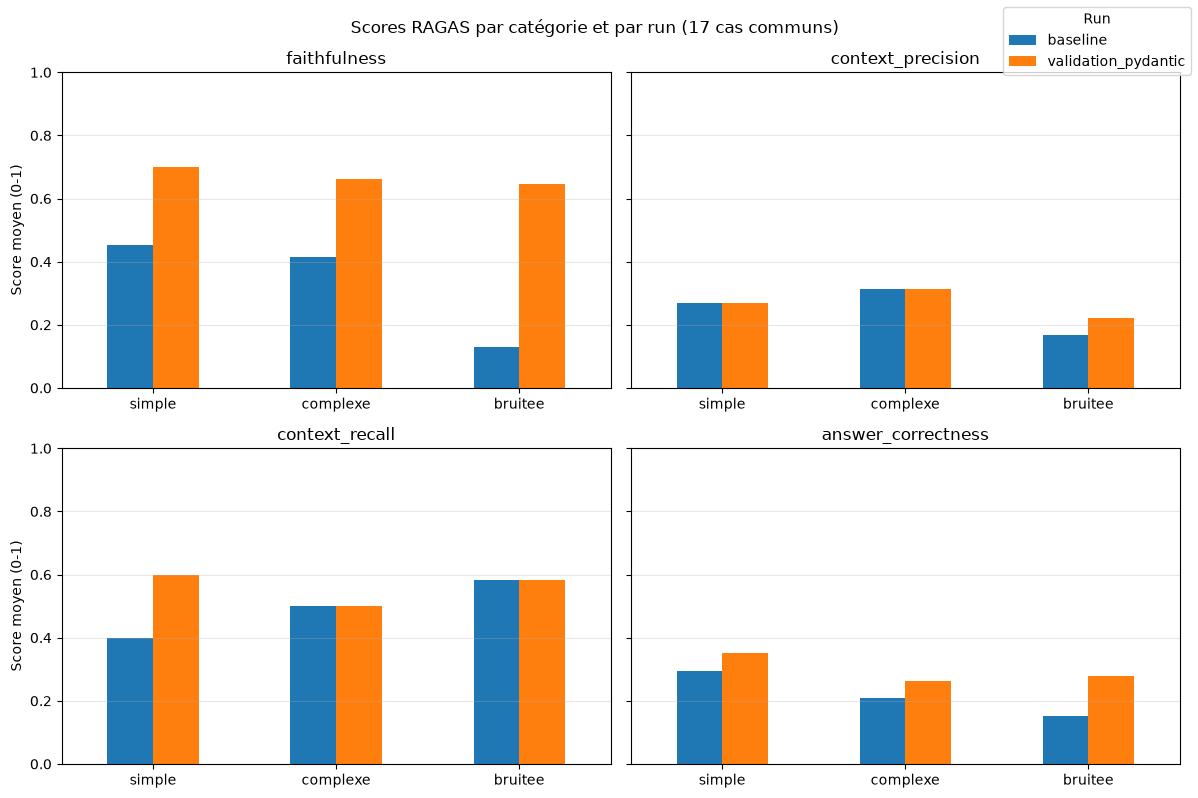

--- Évolution du faithfulness, cas par cas ---


run,baseline,validation_pydantic,delta
id,,,
B6,0.228571,0.000000,-0.229
S3,0.250000,0.250000,0.000
C2,0.000000,0.000000,0.000
S2,0.714286,0.750000,0.036
C6,0.954545,1.000000,0.045
C3,0.428571,0.500000,0.071
B3,0.071429,0.250000,0.179
C5,0.651515,0.869565,0.218
C4,0.450000,0.742857,0.293


In [5]:
dispo = [r for r in RUNS if r in runs]

if len(dispo) < 2:
    print("Comparaison impossible : il faut au moins deux runs dans results/.")
else:
    premier, dernier = dispo[0], dispo[-1]
    df_all = pd.concat([runs[r].assign(run=r) for r in dispo], ignore_index=True)

    # Ne comparer que les cas notés dans TOUS les runs : un cas en échec dans l'un
    # d'eux (ex. erreur 429 côté juge) fausserait la moyenne s'il était compté d'un
    # côté seulement. Les sections 1 et 2, elles, gardent tous les cas de leur run.
    notes = df_all.dropna(subset=METRICS)
    cas_communs = set.intersection(*(set(notes.loc[notes["run"] == r, "id"]) for r in dispo))
    exclus = sorted(set(df_all["id"]) - cas_communs)
    if exclus:
        print(f"Cas exclus de la comparaison (non notés dans tous les runs) : {', '.join(exclus)}")
    print(f"Comparaison sur {len(cas_communs)} cas communs\n")
    comparable = notes[notes["id"].isin(cas_communs)]

    print(f"--- Scores globaux : {premier} vs {dernier} ---")
    globaux = comparable.groupby("run")[METRICS].mean().round(3).reindex(dispo)
    globaux.loc["delta"] = (globaux.loc[dernier] - globaux.loc[premier]).round(3)
    display(globaux)

    print("--- Par catégorie ---")
    par_cat = comparable.groupby(["run", "categorie"])[METRICS].mean().round(3)
    display(par_cat.reindex(pd.MultiIndex.from_product([dispo, ORDRE_CATEGORIES], names=["run", "categorie"])))

    # Un graphique par métrique : chaque groupe = une catégorie, chaque barre = un run
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    for ax, metric in zip(axes.flat, METRICS):
        pivot = par_cat[metric].unstack("run").reindex(ORDRE_CATEGORIES)[dispo]
        pivot.plot(kind="bar", ax=ax, rot=0, legend=False)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
    axes.flat[0].set_ylabel("Score moyen (0-1)")
    axes.flat[2].set_ylabel("Score moyen (0-1)")
    handles, noms = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Run", loc="upper right")
    fig.suptitle(f"Scores RAGAS par catégorie et par run ({len(cas_communs)} cas communs)")
    plt.tight_layout()
    plt.show()

    # Cas par cas : régressions en haut, progrès en bas
    print("--- Évolution du faithfulness, cas par cas ---")
    cas = (
        comparable.pivot(index="id", columns="run", values="faithfulness")[dispo]
        .reindex([i for i in runs[premier]["id"] if i in cas_communs])  # ordre du testset
    )
    cas["delta"] = (cas[dernier] - cas[premier]).round(3)
    display(cas.sort_values("delta"))

## 4. Conclusion

Comparaison sur les **17 cas communs** (S6 a échoué côté juge sur une limite de débit OpenAI, exclu des deux runs).

| Métrique | baseline | validation_pydantic | écart |
|---|---|---|---|
| faithfulness | 0.325 | **0.667** | +0.342 |
| context_precision | 0.248 | 0.268 | +0.020 |
| context_recall | 0.500 | 0.559 | +0.059 |
| answer_correctness | 0.214 | 0.295 | +0.081 |

**Le faithfulness double**, et le gain se concentre là où on l'attendait : la catégorie bruitée passe de 0.129 à 0.646 (simple 0.453 → 0.700, complexe 0.414 → 0.662). Côté comportement, `abstention_accuracy = 12/17 = 70,6 %` : 3 abstentions correctes là où la baseline n'abstenait **jamais**, contre 3 non-détections et 2 faux refus.

**`context_precision` ne bouge quasiment pas (+0.020)** — c'est le contrôle de cohérence du protocole : cette métrique ne dépend que du retrieval, qu'on n'a pas touché. Un écart important aurait signalé une variable parasite.

**Ce qui a changé** : le système n'invente plus, il déclare. C1 (classement de joueurs fictifs) et B4 (fausses citations Reddit) sont devenus des abstentions explicites. La vérification des citations a servi en conditions réelles : sur S5, le modèle a cité `Tearz_in_rain_11j` — un pseudo Reddit, pas un `chunk_id` — retiré automatiquement.

**Ce qui reste à faire** : le retrieval. Les abstentions de S1 et C1 comptent comme des faux refus, mais leur motif est exact — l'information n'était pas dans les chunks récupérés. Le défaut n'a pas disparu, **il est devenu visible**, donc mesurable pour la prochaine étape (retrieval hybride sur les données tabulaires).

**À surveiller** : B6 régresse (0.229 → 0.000), le cas qui teste l'exhaustivité du retrieval.